# Learning curves — SBND diffusion training (EAF)

**Kernel:** CPU-friendly (no CUDA required for this notebook). Training curves
may use the diffusion env; the **Find stop signal** section only reads grid
``out_*.tgz`` products.

Reads `progress.csv` under each config's `OPENAI_LOGDIR`:
`/scratch/7DayLifetime/munjung/anomaly-detection/training/diffusion/<config>/`

Saved figures → `/exp/sbnd/data/users/munjung/anomaly-detection/training/curves/`.

**ICARUS VAE/CAE curves:** use `train/03b_LearningCurves_ICARUS.ipynb`.

**Find stop signal** (below): unpacks stop-signal jobsub campaigns under
`/pnfs/.../out/inference/2026_*__stopsignal_{linear|anisotropic}_ckpt*_T*` and
scores them on CPU. Never runs model inference.


In [8]:
from __future__ import annotations

import csv
import importlib
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
sys.path.insert(0, str(APP_ROOT))

# Notebook kernels keep stale configs.* in sys.modules across edits — force reload.
import configs.paths as _paths_mod
import configs.train_configs as _train_configs_mod

importlib.reload(_paths_mod)
importlib.reload(_train_configs_mod)

from configs.paths import (  # noqa: E402
    DATA_ROOT,
    SCRATCH_ROOT,
    SCRATCH_TRAINING,
    ensure_layout,
    existing_scratch_pools,
    resolve_training_run_root,
)
from configs.train_configs import TRAIN_CONFIGS  # noqa: E402

ensure_layout()
CURVES = DATA_ROOT / "training" / "curves"
CURVES.mkdir(parents=True, exist_ok=True)

RUN_ROOT = resolve_training_run_root()
print("scratch pools:", [str(p) for p in existing_scratch_pools()] or ["<none>"])
print("SCRATCH_ROOT:", SCRATCH_ROOT)
print("RUN_ROOT:", RUN_ROOT)
LEGACY_RESULTS = APP_ROOT / "train" / "diffusion-anomaly" / "results"
CONFIGS = [c.name for c in TRAIN_CONFIGS]

STEP_KEYS = ("step", "steps", "iteration")
TRAIN_LOSS_KEYS = ("loss", "mse", "train_loss")
SMOOTH_WINDOW = 50
PLOT_CHECK_TS = (99, 499, 999)  # subset of saved t=99,199,...,999
PLOT_CHECK_EXTRAS = (
    "reco_wavf_I0.png",
    "time_ffts.png",
    "wire_ffts.png",
)


def plot_check_files(ts: tuple[int, ...] = PLOT_CHECK_TS) -> list[str]:
    """Original + diffusion/reco at selected t + waveform/FFT extras."""
    files = ["img.png"]
    for t in ts:
        files.append(f"diffusion_t{t}.png")
        files.append(f"reconstructed_t{t}.png")
    files.extend(PLOT_CHECK_EXTRAS)
    return files


def load_progress(path: Path) -> list[dict]:
    with path.open() as f:
        return list(csv.DictReader(f))


def safe_float(value) -> float | None:
    if value in (None, ""):
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def resolve_progress(name: str) -> Path | None:
    for p in (
        RUN_ROOT / name / "progress.csv",
        DATA_ROOT / "training" / "diffusion" / name / "progress.csv",
    ):
        if p.is_file():
            return p
    return None


def resolve_log_dir(name: str) -> Path | None:
    for root in (RUN_ROOT, DATA_ROOT / "training" / "diffusion"):
        d = root / name
        if (d / "progress.csv").is_file() or (d / "validation-plots").is_dir():
            return d
    return None


def resolve_run(name: str) -> tuple[Path | None, Path | None, str]:
    """Return (progress_csv, log_dir, label). Falls back to LEGACY once."""
    prog = resolve_progress(name)
    if prog is not None:
        return prog, prog.parent, name
    if name in ("linear", "anisotropic") and (LEGACY_RESULTS / "progress.csv").is_file():
        return (
            LEGACY_RESULTS / "progress.csv",
            LEGACY_RESULTS,
            "LEGACY shared results/ (pre-OPENAI_LOGDIR fix)",
        )
    return None, None, name


def step_key(rows: list[dict]) -> str:
    return next(k for k in STEP_KEYS if k in rows[0])


def train_loss_key(rows: list[dict]) -> str:
    key = next((k for k in TRAIN_LOSS_KEYS if k in rows[0]), None)
    if key is None:
        key = next(k for k in rows[0] if k and "loss" in k.lower() and not k.startswith("val-"))
    return key


def row_has_validation(row: dict) -> bool:
    return any(row.get(f"val-loss_q{i}") not in (None, "") for i in range(4))


def mean_quartile(row: dict, prefix: str) -> float | None:
    vals = [
        v
        for i in range(4)
        if (v := safe_float(row.get(f"{prefix}_q{i}"))) is not None
    ]
    return float(np.mean(vals)) if vals else None


def extract_train_series(rows: list[dict]) -> tuple[np.ndarray, np.ndarray]:
    sk = step_key(rows)
    lk = train_loss_key(rows)
    steps, loss = [], []
    for row in rows:
        s = safe_float(row.get(sk))
        y = safe_float(row.get(lk))
        if s is None or y is None:
            continue
        steps.append(s)
        loss.append(y)
    return np.array(steps), np.array(loss)


def extract_validation_series(rows: list[dict], metric: str = "val-loss") -> tuple[np.ndarray, np.ndarray]:
    sk = step_key(rows)
    steps, vals = [], []
    for row in rows:
        if not row_has_validation(row):
            continue
        s = safe_float(row.get(sk))
        v = mean_quartile(row, metric)
        if s is None or v is None:
            continue
        steps.append(s)
        vals.append(v)
    return np.array(steps), np.array(vals)


def smooth_curve(steps: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if len(y) <= 20:
        return steps, y
    w = max(5, len(y) // SMOOTH_WINDOW)
    kernel = np.ones(w) / w
    smooth = np.convolve(y, kernel, mode="valid")
    return steps[: len(smooth)], smooth


def plot_metric_curves(
    series_by_label: dict[str, tuple[np.ndarray, np.ndarray]],
    *,
    title_prefix: str,
    ylabel: str,
    out_name: str,
    ylim: tuple[float, float] | None = (0, 0.01),
) -> Path | None:
    if not series_by_label:
        print(f"No data for {title_prefix}")
        return None
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for label, (steps, y) in series_by_label.items():
        axes[0].plot(steps, y, label=label, alpha=0.85)
        sx, sy = smooth_curve(steps, y)
        axes[1].plot(sx, sy, label=label)
    axes[0].set_title(f"{title_prefix} (raw)")
    axes[1].set_title(f"{title_prefix} (smoothed)")
    for ax in axes:
        ax.set_xlabel("step")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        if ylim is not None:
            ax.set_ylim(*ylim)
    out = CURVES / out_name
    fig.savefig(out, bbox_inches="tight")
    print("saved", out)
    plt.show()
    return out


def list_plot_check_steps(log_dir: Path, sampler: str = "ddim") -> list[int]:
    vp = log_dir / "validation-plots"
    if not vp.is_dir():
        return []
    pat = re.compile(rf"step-(\d+)-{sampler}$")
    steps = []
    for d in vp.iterdir():
        m = pat.match(d.name)
        if m:
            steps.append(int(m.group(1)))
    return sorted(steps)


def plot_check_dir(log_dir: Path, step: int, sampler: str = "ddim", img_idx: int = 0) -> Path:
    return log_dir / "validation-plots" / f"step-{step}-{sampler}" / f"img-{img_idx}"


print("RUN_ROOT", RUN_ROOT, "exists=", RUN_ROOT.exists())
print("LEGACY_RESULTS", LEGACY_RESULTS, "progress=", (LEGACY_RESULTS / "progress.csv").is_file())
used_legacy = False
for name in CONFIGS:
    prog, log_dir, label = resolve_run(name)
    if label.startswith("LEGACY"):
        if used_legacy:
            print(f"  {name}: skipped (legacy already shown)")
            continue
        used_legacy = True
        print("WARNING: using shared", prog, "- restart training for per-config dirs")
    n_val = len(list_plot_check_steps(log_dir)) if log_dir else 0
    print(f"  {name}: progress={prog}  log_dir={log_dir}  plot_checks={n_val}")


scratch pools: ['<none>']
SCRATCH_ROOT: None
RUN_ROOT: /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion
RUN_ROOT /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion exists= True
LEGACY_RESULTS /exp/sbnd/app/users/munjung/anomaly-detection/train/diffusion-anomaly/results progress= True
  linear: progress=/exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/linear/progress.csv  log_dir=/exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/linear  plot_checks=0
  cosine: progress=None  log_dir=None  plot_checks=0
  ramp: progress=None  log_dir=None  plot_checks=0
  anisotropic: progress=/exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/anisotropic/progress.csv  log_dir=/exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/anisotropic  plot_checks=0
  pred_xstart: progress=None  log_dir=None  plot_checks=0


linear: 501 train rows from /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/linear/progress.csv
anisotropic: 536 train rows from /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/anisotropic/progress.csv
saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/all_configs_train_curves.pdf


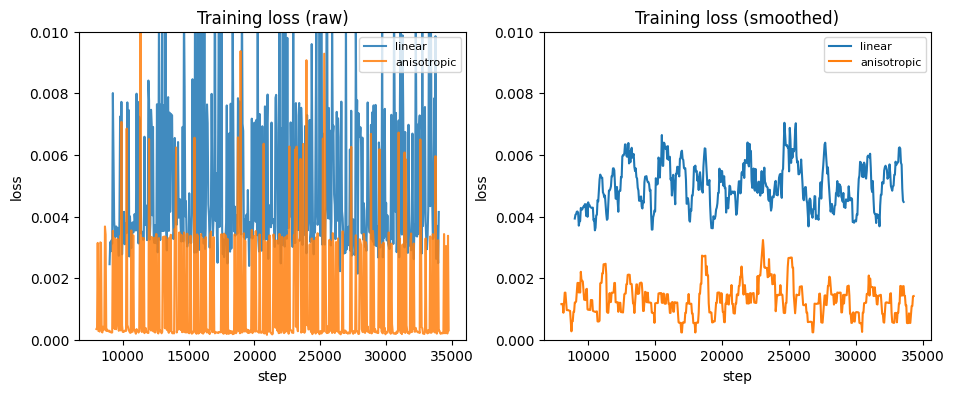

PosixPath('/exp/sbnd/data/users/munjung/anomaly-detection/training/curves/all_configs_train_curves.pdf')

In [9]:
# --- Training loss curves ---
train_series: dict[str, tuple[np.ndarray, np.ndarray]] = {}
used_legacy = False

for name in CONFIGS:
    prog, _, label = resolve_run(name)
    if prog is None:
        continue
    if label.startswith("LEGACY"):
        if used_legacy:
            continue
        used_legacy = True
    rows = load_progress(prog)
    if not rows:
        continue
    steps, loss = extract_train_series(rows)
    if len(steps) == 0:
        continue
    train_series[label] = (steps, loss)
    print(f"{label}: {len(steps)} train rows from {prog}")

plot_metric_curves(
    train_series,
    title_prefix="Training loss",
    ylabel="loss",
    out_name="all_configs_train_curves.pdf",
)


linear: 50 validation rows (loss) from /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/linear/progress.csv
anisotropic: 53 validation rows (loss) from /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/anisotropic/progress.csv
saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/all_configs_val_loss_curves.pdf


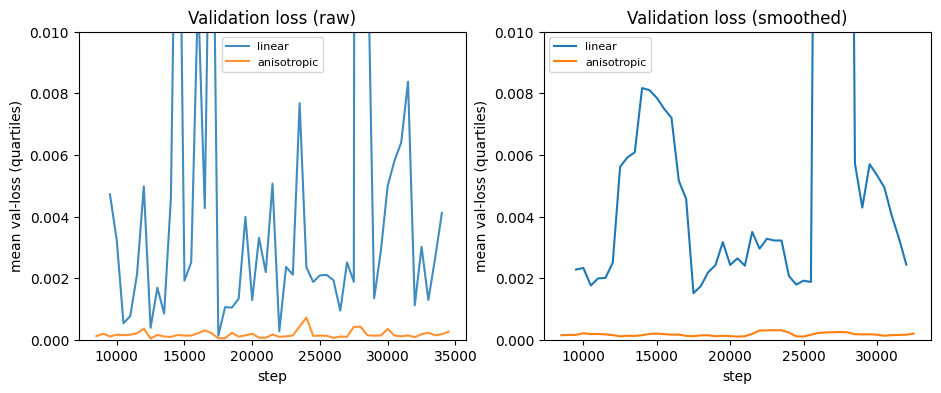

saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/all_configs_val_mse_curves.pdf


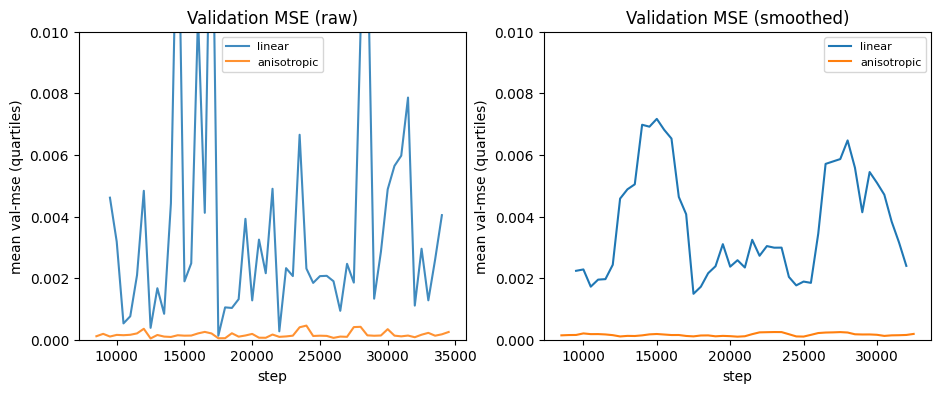

PosixPath('/exp/sbnd/data/users/munjung/anomaly-detection/training/curves/all_configs_val_mse_curves.pdf')

In [10]:
# --- Validation loss curves (logged every validation_interval=500 steps) ---
val_loss_series: dict[str, tuple[np.ndarray, np.ndarray]] = {}
val_mse_series: dict[str, tuple[np.ndarray, np.ndarray]] = {}
used_legacy = False

for name in CONFIGS:
    prog, _, label = resolve_run(name)
    if prog is None:
        continue
    if label.startswith("LEGACY"):
        if used_legacy:
            continue
        used_legacy = True
    rows = load_progress(prog)
    steps_l, vloss = extract_validation_series(rows, "val-loss")
    steps_m, vmse = extract_validation_series(rows, "val-mse")
    if len(steps_l):
        val_loss_series[label] = (steps_l, vloss)
        print(f"{label}: {len(steps_l)} validation rows (loss) from {prog}")
    if len(steps_m):
        val_mse_series[label] = (steps_m, vmse)

plot_metric_curves(
    val_loss_series,
    title_prefix="Validation loss",
    ylabel="mean val-loss (quartiles)",
    out_name="all_configs_val_loss_curves.pdf",
)

plot_metric_curves(
    val_mse_series,
    title_prefix="Validation MSE",
    ylabel="mean val-mse (quartiles)",
    out_name="all_configs_val_mse_curves.pdf",
)


## Training plot checks (`validation-plots/`)

During training, `plot_interval=10000` triggers reconstruction sanity checks saved under:

`{OPENAI_LOGDIR}/validation-plots/step-<N>-{ddim|ddpm}/img-<i>/`

Each check dir has `diffusion_t{t}.png` / `reconstructed_t{t}.png` for
`t = 99, 199, …, 999`. Below shows **t = 99, 499, 999** plus waveform/FFT panels
(latest checkpoint per config; DDIM). Nothing appears until step 10k.


In [11]:
# --- Display saved validation plot checks ---
SAMPLER = "ddim"  # or "ddpm"
IMG_IDX = 3
STEP = None  # None -> latest available step per config
# Change PLOT_CHECK_TS in the setup cell to pick other t's (any of 99,199,...,999)

shown_any = False
for name in CONFIGS:
    log_dir = resolve_log_dir(name)
    if log_dir is None and name in ("linear", "anisotropic"):
        log_dir = LEGACY_RESULTS if LEGACY_RESULTS.is_dir() else None
    if log_dir is None:
        continue

    steps = list_plot_check_steps(log_dir, SAMPLER)
    if not steps:
        print(f"{name}: no validation-plots yet (first batch at step 10000)")
        continue

    step = STEP if STEP is not None else steps[-1]
    if step not in steps:
        print(f"{name}: step {step} not found; available: {steps}")
        continue

    check_dir = plot_check_dir(log_dir, step, SAMPLER, IMG_IDX)
    if not check_dir.is_dir():
        print(f"{name}: missing {check_dir}")
        continue

    # Layout: row0 = original | (blank) | (blank)
    #         then one row per t: diffusion_t | reconstructed_t | (blank on last unused)
    #         final row = waveform / FFT extras
    n_t = len(PLOT_CHECK_TS)
    n_rows = 1 + n_t + 1  # img row + per-t rows + extras
    fig, axes = plt.subplots(n_rows, 3, figsize=(14, 3.2 * n_rows))
    fig.suptitle(
        f"{name} — step {step} ({SAMPLER}, img {IMG_IDX}); t={list(PLOT_CHECK_TS)}",
        fontsize=12,
    )

    # Row 0: original image
    path = check_dir / "img.png"
    axes[0, 0].set_title("img.png", fontsize=9)
    axes[0, 0].axis("off")
    if path.is_file():
        axes[0, 0].imshow(mpimg.imread(path))
    else:
        axes[0, 0].text(0.5, 0.5, "missing", ha="center", va="center", transform=axes[0, 0].transAxes)
    for ax in axes[0, 1:]:
        ax.axis("off")

    # Rows 1..n_t: diffusion + reconstructed at each t
    for r, t in enumerate(PLOT_CHECK_TS, start=1):
        for c, kind in enumerate(("diffusion", "reconstructed")):
            fname = f"{kind}_t{t}.png"
            ax = axes[r, c]
            ax.set_title(fname, fontsize=9)
            ax.axis("off")
            path = check_dir / fname
            if path.is_file():
                ax.imshow(mpimg.imread(path))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        axes[r, 2].axis("off")

    # Last row: extras
    for ax, fname in zip(axes[-1], PLOT_CHECK_EXTRAS):
        ax.set_title(fname, fontsize=9)
        ax.axis("off")
        path = check_dir / fname
        if path.is_file():
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    ts_tag = "-".join(str(t) for t in PLOT_CHECK_TS)
    out = CURVES / f"plot_check_{name}_step{step}_{SAMPLER}_t{ts_tag}.pdf"
    fig.savefig(out, bbox_inches="tight")
    print(f"{name}: saved {out}")
    # also list which smaller-t files exist on disk
    available_t = sorted(
        int(p.stem.split("_t")[1])
        for p in check_dir.glob("diffusion_t*.png")
    )
    print(f"{name}: diffusion_t* available: {available_t}")
    plt.show()
    shown_any = True

if not shown_any:
    print("No plot-check PNGs found yet. They are written every plot_interval=10000 training steps.")


linear: no validation-plots yet (first batch at step 10000)
anisotropic: no validation-plots yet (first batch at step 10000)
No plot-check PNGs found yet. They are written every plot_interval=10000 training steps.


# Find stop signal -- on FNAL

Judge when to stop training from **finished grid jobs**, not from live GPU inference.

Campaigns (jobsub) look like:
`/pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference/<stamp>__stopsignal_<config>_ckpt<step>_T<tag>/`

Prefer complete `T100-200` campaigns when present (≥12 `out_*.tgz`); otherwise use finished `T200`.
Reconstruction method: **ddim2ddim**.

| Probe | What it uses |
|---|---|
| **Primary** | AD scores from `*_arrays.npz` (noise-region residual RMS). AUC if both healthy + anomaly patches are present; otherwise anomaly-score trends only. |
| **Secondary** | Noise-region residual + time/wire FFT match on the same grid arrays; plus training `validation-plots/` gallery when available. |

This section **never** imports torch / never touches CUDA.

For **T-sweep image panels** (healthy/coh across T), see `inference/06_InspectTSweep.ipynb`.


In [12]:
# --- Find stop signal: discover finished grid campaigns (CPU only) ---
# Self-contained: safe to run without re-executing the notebook imports cell.
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

import configs.paths as _paths_mod

importlib.reload(_paths_mod)
from configs.paths import DATA_ROOT  # noqa: E402

import train.stop_signal_eval as stop_eval

importlib.reload(stop_eval)

CURVES = DATA_ROOT / "training" / "curves"
CURVES.mkdir(parents=True, exist_ok=True)
STOP_DIR = CURVES / "stop_signals"
STOP_DIR.mkdir(parents=True, exist_ok=True)
UNPACK_ROOT = DATA_ROOT / "inference" / "grid_unpacked" / "stopsignal"
UNPACK_ROOT.mkdir(parents=True, exist_ok=True)

PNFS_INFERENCE = Path("/pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference")
STOP_CONFIGS = ("linear", "anisotropic", "gray")  # gray = Gray iterE EMA @111k baseline
# Prefer multi-T campaigns when present; otherwise keep finished single-T (e.g. T200).
# min_tgz=12 → do not displace a finished T200 campaign with a half-done T100-200 job.
PREFER_T_TAG = "100-200"
MIN_TGZ = 12
MODE = "ddim2ddim"
SCORE_KIND = "noise_rms"
PATIENCE_STEPS = 20000
MIN_DELTA_AUC = 0.005
MIN_DELTA_ANOM = 1e-4  # soft stop on anomaly_mean when AUC unavailable

# Name sets for labeling (same stems in healthy_patches and coh_noise_patches).
# Coh-only grid campaigns must NOT use healthy_names — see primary cell.
HEALTHY_NPZ_DIR = DATA_ROOT / "samples" / "defects" / "healthy_patches"
ANOMALY_NPZ_DIR = DATA_ROOT / "samples" / "defects" / "coh_noise_patches"
healthy_names = stop_eval.load_name_set(HEALTHY_NPZ_DIR)
anomaly_names = stop_eval.load_name_set(ANOMALY_NPZ_DIR)
print(f"label sets: healthy={len(healthy_names)} anomaly={len(anomaly_names)}")

all_camps = stop_eval.discover_stopsignal_campaigns(
    PNFS_INFERENCE, configs=STOP_CONFIGS, require_tgz=True
)
print(f"finished campaigns with tarballs: {len(all_camps)}")
for c in all_camps:
    print(f"  {c.config:12s} step={c.step:6d} T={c.t_tag:8s} n_tgz={c.n_tgz}  {c.path.name}")

camp_map = stop_eval.prefer_campaigns(
    all_camps, prefer_t_tag=PREFER_T_TAG, min_tgz=MIN_TGZ
)
print(f"\nselected {len(camp_map)} (probe, config, step) triples (prefer T-tag={PREFER_T_TAG!r}, min_tgz={MIN_TGZ}):")
for (probe, cfg, step), c in sorted(camp_map.items()):
    print(f"  {probe:7s} {cfg:12s} @{step} → {c.path.name} (T={c.t_tag}, n_tgz={c.n_tgz})")


label sets: healthy=36 anomaly=36
finished campaigns with tarballs: 24
  linear       step= 10000 T=200      n_tgz=12  2026_09_15_162530__stopsignal_linear_ckpt010000_T200
  linear       step= 20000 T=200      n_tgz=12  2026_09_15_162550__stopsignal_linear_ckpt020000_T200
  linear       step= 30000 T=200      n_tgz=12  2026_09_15_162609__stopsignal_linear_ckpt030000_T200
  anisotropic  step= 10000 T=200      n_tgz=12  2026_09_15_162630__stopsignal_anisotropic_ckpt010000_T200
  anisotropic  step= 20000 T=200      n_tgz=12  2026_09_15_162649__stopsignal_anisotropic_ckpt020000_T200
  anisotropic  step= 30000 T=200      n_tgz=12  2026_09_15_162711__stopsignal_anisotropic_ckpt030000_T200
  linear       step= 10000 T=100-200  n_tgz=12  2026_09_15_180928__stopsignal_linear_ckpt010000_T100-200
  linear       step= 20000 T=100-200  n_tgz=12  2026_09_15_180952__stopsignal_linear_ckpt020000_T100-200
  linear       step= 30000 T=100-200  n_tgz=12  2026_09_15_181011__stopsignal_linear_ckpt030000_T1

In [13]:
# --- Unpack selected campaigns (idempotent) ---
unpacked_map: dict[tuple[str, str, int], Path] = {}
for key, camp in sorted(camp_map.items()):
    dest = stop_eval.unpack_campaign(camp.path, UNPACK_ROOT)
    n_arr = len(list(dest.rglob("*_arrays.npz")))
    print(f"{camp.probe}/{camp.config}@{camp.step}: unpacked → {dest.name}  arrays.npz={n_arr}")
    unpacked_map[key] = dest


coh/anisotropic@10000: unpacked → 2026_09_15_181030__stopsignal_anisotropic_ckpt010000_T100-200  arrays.npz=72
coh/anisotropic@20000: unpacked → 2026_09_15_181050__stopsignal_anisotropic_ckpt020000_T100-200  arrays.npz=72
coh/anisotropic@30000: unpacked → 2026_09_15_181110__stopsignal_anisotropic_ckpt030000_T100-200  arrays.npz=72
coh/gray@111000: unpacked → 2026_09_15_212134__stopsignal_gray_ckpt111000_T200  arrays.npz=36
coh/linear@10000: unpacked → 2026_09_15_180928__stopsignal_linear_ckpt010000_T100-200  arrays.npz=72
coh/linear@20000: unpacked → 2026_09_15_180952__stopsignal_linear_ckpt020000_T100-200  arrays.npz=72
coh/linear@30000: unpacked → 2026_09_15_181011__stopsignal_linear_ckpt030000_T100-200  arrays.npz=72
healthy/anisotropic@10000: unpacked → 2026_09_15_191656__stopsignal_healthy_anisotropic_ckpt010000_T200  arrays.npz=36
healthy/anisotropic@20000: unpacked → 2026_09_15_222514__stopsignal_healthy_anisotropic_ckpt020000_T200-400-600-800-1000  arrays.npz=180
healthy/anisot

### Example reconstructions (before proxies)

Spot-check a few **healthy** vs **coh_noise** grid outputs (original / reco / saliency) from a matched `(config, step)` pair. CPU only — reads unpacked `*_arrays.npz`.


examples from anisotropic@30000  T=200
saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/stop_signals/examples_healthy_anisotropic_ckpt030000_T200.pdf


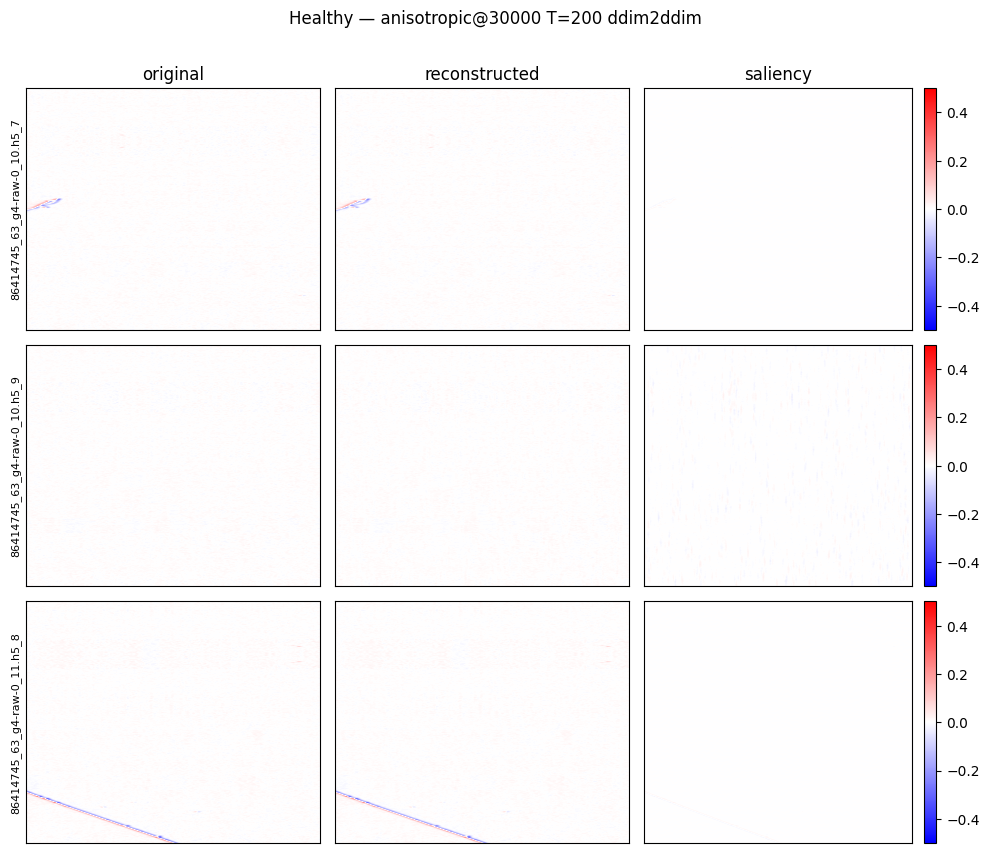

saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/stop_signals/examples_coh_anisotropic_ckpt030000_T200.pdf


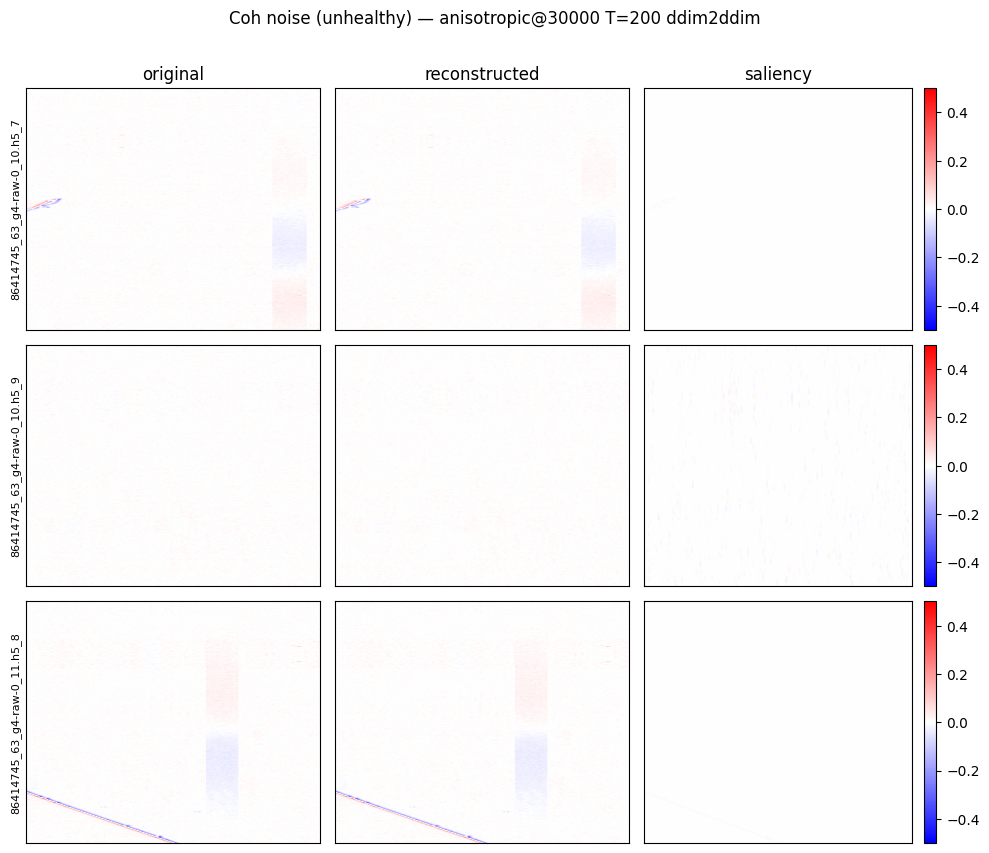

In [14]:
# --- Example healthy vs coh_noise reconstructions (CPU, grid arrays only) ---
N_EXAMPLES = 3
T_EX = 200
# Prefer a mid/late training step that has both probes; fall back to any paired step.
EXAMPLE_PREFER = [
    ("anisotropic", 30000),
    ("linear", 30000),
    ("gray", 111000),
    ("anisotropic", 20000),
    ("linear", 20000),
]

by_cfg_step_ex: dict[tuple[str, int], dict[str, Path]] = {}
for (probe, cfg, step), dest in unpacked_map.items():
    by_cfg_step_ex.setdefault((cfg, step), {})[probe] = dest

example_key = None
for cand in EXAMPLE_PREFER:
    probes = by_cfg_step_ex.get(cand, {})
    if "healthy" in probes and "coh" in probes:
        example_key = cand
        break
if example_key is None:
    for key, probes in sorted(by_cfg_step_ex.items()):
        if "healthy" in probes and "coh" in probes:
            example_key = key
            break

if example_key is None:
    print("No (config, step) with both healthy and coh unpacked yet — skip examples.")
else:
    cfg_ex, step_ex = example_key
    print(f"examples from {cfg_ex}@{step_ex}  T={T_EX}")

    def _load_examples(dest: Path, T: int, n: int) -> list[dict]:
        files = stop_eval.iter_arrays_npz(dest, T, MODE)
        out = []
        for fp in files[:n]:
            z = np.load(fp)
            out.append(
                {
                    "path": fp,
                    "name": Path(str(z["input_filename"])).name if "input_filename" in z.files else fp.name,
                    "original": np.squeeze(z["original"][0]),
                    "reconstructed": np.squeeze(z["reconstructed"][0]),
                    "saliency": np.squeeze(
                        z["saliency"][0] if "saliency" in z.files else z["reconstructed"][0] - z["original"][0]
                    ),
                }
            )
        return out

    def _plot_examples(rows: list[dict], title: str, out_pdf: Path) -> None:
        if not rows:
            print(f"{title}: no arrays")
            return
        fig, axes = plt.subplots(len(rows), 3, figsize=(10, 2.8 * len(rows)))
        if len(rows) == 1:
            axes = np.array([axes])
        panels = ("original", "reconstructed", "saliency")
        vmins = (-1.0, -1.0, -0.5)
        vmaxs = (1.0, 1.0, 0.5)
        for r, row in enumerate(rows):
            for c, (key, vmin, vmax) in enumerate(zip(panels, vmins, vmaxs)):
                ax = axes[r, c]
                im = ax.imshow(
                    row[key], aspect="auto", origin="lower", cmap="bwr", vmin=vmin, vmax=vmax
                )
                ax.set_xticks([])
                ax.set_yticks([])
                if r == 0:
                    ax.set_title(key)
                if c == 0:
                    ax.set_ylabel(row["name"][:28], fontsize=8)
                if c == 2:
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.suptitle(title, y=1.01)
        fig.tight_layout()
        fig.savefig(out_pdf, bbox_inches="tight")
        print(f"saved {out_pdf}")
        plt.show()

    healthy_ex = _load_examples(by_cfg_step_ex[example_key]["healthy"], T_EX, N_EXAMPLES)
    coh_ex = _load_examples(by_cfg_step_ex[example_key]["coh"], T_EX, N_EXAMPLES)
    _plot_examples(
        healthy_ex,
        f"Healthy — {cfg_ex}@{step_ex} T={T_EX} {MODE}",
        STOP_DIR / f"examples_healthy_{cfg_ex}_ckpt{step_ex:06d}_T{T_EX}.pdf",
    )
    _plot_examples(
        coh_ex,
        f"Coh noise (unhealthy) — {cfg_ex}@{step_ex} T={T_EX} {MODE}",
        STOP_DIR / f"examples_coh_{cfg_ex}_ckpt{step_ex:06d}_T{T_EX}.pdf",
    )


In [15]:
# --- Primary: AD metrics from grid arrays.npz ---
# Coh and healthy campaigns share patch stems; label by campaign probe.
# When both probes exist at the same (config, step, T), merge scores → AUC.

from collections import defaultdict

primary_by_config: dict[str, list[dict]] = {c: [] for c in STOP_CONFIGS}
primary_cache = STOP_DIR / f"primary_from_grid_{SCORE_KIND}.json"

by_cfg_step: dict[tuple[str, int], dict[str, object]] = defaultdict(dict)
for (probe, cfg, step), dest in sorted(unpacked_map.items()):
    by_cfg_step[(cfg, step)][probe] = (camp_map[(probe, cfg, step)], dest)

for (cfg, step), probes in sorted(by_cfg_step.items()):
    any_camp = next(iter(probes.values()))[0]
    Ts = any_camp.timesteps or [200]
    for T in Ts:
        healthy_scores: list[float] = []
        anomaly_scores: list[float] = []
        secondary_rows: list[dict] = []
        campaigns_used: list[str] = []
        for probe, (camp, dest) in probes.items():
            files = stop_eval.iter_arrays_npz(dest, T, MODE)
            if not files:
                print(f"skip {probe}/{cfg}@{step} T={T}: no arrays")
                continue
            default = "healthy" if probe == "healthy" else "anomaly"
            campaigns_used.append(camp.path.name)
            for fp in files:
                scores, prox_list, fname = stop_eval.score_arrays_file(
                    fp, score_kind=SCORE_KIND
                )
                for sc, prox in zip(scores, prox_list):
                    if default == "healthy":
                        healthy_scores.append(sc)
                    else:
                        anomaly_scores.append(sc)
                    secondary_rows.append({"file": fname, "label": default, **prox})

        if not healthy_scores and not anomaly_scores:
            continue
        metrics = stop_eval.roc_auc_youden(
            np.asarray(healthy_scores, dtype=float),
            np.asarray(anomaly_scores, dtype=float),
        )
        sec_mean = stop_eval._mean_prox(secondary_rows) if secondary_rows else {}
        out_row = {
            "config": cfg,
            "step": step,
            "T": T,
            "t_tag": any_camp.t_tag,
            "campaigns": campaigns_used,
            "score_kind": SCORE_KIND,
            "n_healthy": len(healthy_scores),
            "n_anomaly": len(anomaly_scores),
            "healthy_mean": float(np.mean(healthy_scores)) if healthy_scores else None,
            "anomaly_mean": float(np.mean(anomaly_scores)) if anomaly_scores else None,
            "anomaly_std": float(np.std(anomaly_scores)) if anomaly_scores else None,
            **metrics,
            "secondary_mean": sec_mean,
        }
        primary_by_config[cfg].append(out_row)
        print(
            f"{cfg}@{step} T={T}: n_hlthy={out_row['n_healthy']} n_anom={out_row['n_anomaly']} "
            f"hlthy_mean={out_row['healthy_mean']} anom_mean={out_row['anomaly_mean']} AUC={out_row['auc']}"
        )

for cfg in primary_by_config:
    primary_by_config[cfg].sort(key=lambda r: (int(r["step"]), int(r["T"])))

stop_eval.save_json(
    primary_cache,
    {"score_kind": SCORE_KIND, "mode": MODE, "by_config": primary_by_config},
)
print(f"saved {primary_cache}")


skip healthy/anisotropic@10000 T=100: no arrays
anisotropic@10000 T=100: n_hlthy=0 n_anom=36 hlthy_mean=None anom_mean=0.00046065140862932186 AUC=None
anisotropic@10000 T=200: n_hlthy=36 n_anom=36 hlthy_mean=0.0004864491128958414 anom_mean=0.0004930834113137293 AUC=0.5339506172839505
skip healthy/anisotropic@20000 T=100: no arrays
anisotropic@20000 T=100: n_hlthy=0 n_anom=36 hlthy_mean=None anom_mean=0.001174959502337224 AUC=None
anisotropic@20000 T=200: n_hlthy=36 n_anom=36 hlthy_mean=0.0019451272400890637 anom_mean=0.0019753355306805533 AUC=0.5493827160493827
skip healthy/anisotropic@30000 T=100: no arrays
anisotropic@30000 T=100: n_hlthy=0 n_anom=36 hlthy_mean=None anom_mean=0.001444229128649614 AUC=None
anisotropic@30000 T=200: n_hlthy=36 n_anom=36 hlthy_mean=0.0022373456273971732 anom_mean=0.002262900513952783 AUC=0.5362654320987654
gray@111000 T=200: n_hlthy=36 n_anom=36 hlthy_mean=0.009254095786398832 anom_mean=0.010820875414388182 AUC=0.595679012345679
skip healthy/linear@10000

saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/stop_signals/primary_from_grid_T200_noise_rms.pdf


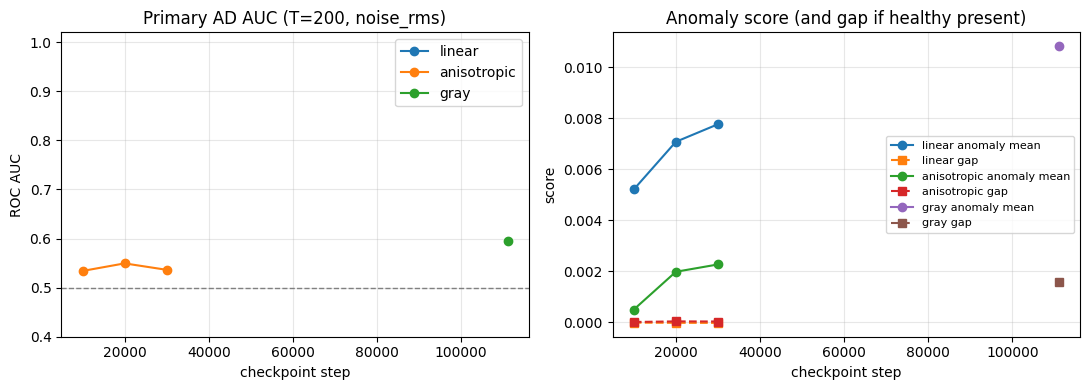


=== Early-stop verdict ===
linear: [CONTINUE] Keep training; best so far step=30000 AUC=0.36034 (last step=30000 AUC=0.36034).
anisotropic: [CONTINUE] Keep training; best so far step=20000 AUC=0.549383 (last step=30000 AUC=0.536265).
gray: [CONTINUE] Need ≥2 finite AUC points.


In [16]:
# --- Primary plots + early-stop verdict ---
T_PLOT = 200  # primary curves at this T (also have 100 when T100-200 campaigns finish)

if not any(primary_by_config.values()):
    print("No primary grid results. Are out_*.tgz present under PNFS_INFERENCE?")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for cfg, rows in primary_by_config.items():
        rows_t = [r for r in rows if int(r["T"]) == T_PLOT]
        if not rows_t:
            rows_t = rows  # fall back
        steps = [int(r["step"]) for r in rows_t]
        aucs = [r.get("auc") for r in rows_t]
        anom = [r.get("anomaly_mean") for r in rows_t]
        axes[0].plot(steps, aucs, marker="o", label=cfg)
        axes[1].plot(steps, anom, marker="o", label=f"{cfg} anomaly mean")
        # if healthy present, also plot gap
        gaps = []
        for r in rows_t:
            a, h = r.get("anomaly_mean"), r.get("healthy_mean")
            gaps.append((a - h) if (a is not None and h is not None) else None)
        if any(g is not None for g in gaps):
            axes[1].plot(steps, gaps, marker="s", ls="--", label=f"{cfg} gap")
    axes[0].set_xlabel("checkpoint step")
    axes[0].set_ylabel("ROC AUC")
    axes[0].set_title(f"Primary AD AUC (T={T_PLOT}, {SCORE_KIND})")
    axes[0].set_ylim(0.4, 1.02)
    axes[0].axhline(0.5, color="grey", ls="--", lw=1)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].set_xlabel("checkpoint step")
    axes[1].set_ylabel("score")
    axes[1].set_title("Anomaly score (and gap if healthy present)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    out = STOP_DIR / f"primary_from_grid_T{T_PLOT}_{SCORE_KIND}.pdf"
    fig.savefig(out, bbox_inches="tight")
    print(f"saved {out}")
    plt.show()

    print("\n=== Early-stop verdict ===")
    for cfg, rows in primary_by_config.items():
        rows_t = [r for r in rows if int(r["T"]) == T_PLOT] or rows
        steps = [int(r["step"]) for r in rows_t]
        aucs = [r.get("auc") for r in rows_t]
        if all(a is None for a in aucs):
            print(
                f"{cfg}: AUC unavailable (anomaly-only / coh list). "
                "Submit healthy+coh at the same checkpoints for a full primary stop."
            )
            # Soft proxy: higher anomaly residual ≈ stronger detection signal.
            anoms = [r.get("anomaly_mean") for r in rows_t]
            v = stop_eval.early_stop_verdict(
                steps,
                anoms,
                patience_steps=PATIENCE_STEPS,
                min_delta=MIN_DELTA_ANOM,
                metric_name="anomaly_mean",
            )
            print(
                f"{cfg} [soft / anomaly_mean]: "
                f"[{'STOP' if v['stop'] else 'CONTINUE'}] {v['reason']}"
            )
            continue
        v = stop_eval.early_stop_verdict(
            steps,
            aucs,
            patience_steps=PATIENCE_STEPS,
            min_delta=MIN_DELTA_AUC,
            metric_name="AUC",
        )
        print(f"{cfg}: [{'STOP' if v['stop'] else 'CONTINUE'}] {v['reason']}")


### Secondary proxies (from the same grid arrays)

Computed on every scored patch in the unpacked campaigns (CPU):
noise-region residual RMS, time/wire FFT relative L2, background texture ratio.
Also shows training `validation-plots/` PNGs when present on scratch/exp.


In [17]:
# --- Secondary: aggregate proxies from grid (reuse primary secondary_mean) ---
secondary_by_config: dict[str, list[dict]] = {c: [] for c in STOP_CONFIGS}
secondary_cache = STOP_DIR / "secondary_from_grid.json"

for cfg, rows in primary_by_config.items():
    for r in rows:
        prox = r.get("secondary_mean") or {}
        T = int(r["T"])
        secondary_by_config[cfg].append(
            {
                "config": cfg,
                "step": int(r["step"]),
                "T": T,
                "by_T": {str(T): prox},
                "campaigns": r.get("campaigns"),
            }
        )
        print(
            f"{cfg}@{r['step']} T={T}: noise_resid={prox.get('noise_resid_rms')} "
            f"fft_wire_mid={prox.get('fft_wire_midband_rel_l2')} "
            f"bg_ratio={prox.get('bg_texture_std_ratio')}"
        )

for cfg in secondary_by_config:
    secondary_by_config[cfg].sort(key=lambda r: (int(r["step"]), int(r["T"])))

stop_eval.save_json(secondary_cache, {"by_config": secondary_by_config})
print(f"saved {secondary_cache}")


linear@10000 T=100: noise_resid=0.005110793345347376 fft_wire_mid=0.40565288289088086 bg_ratio=0.6959237237465964
linear@10000 T=200: noise_resid=0.005213253188427551 fft_wire_mid=0.42335390089883845 bg_ratio=0.6852927813807442
linear@20000 T=100: noise_resid=0.006939932836615068 fft_wire_mid=0.5159073509370714 bg_ratio=0.6105051325401535
linear@20000 T=200: noise_resid=0.007084605831333002 fft_wire_mid=0.5373329873103772 bg_ratio=0.5956186232633907
linear@30000 T=100: noise_resid=0.007612942284771454 fft_wire_mid=0.5465553054768795 bg_ratio=0.5855466688448863
linear@30000 T=200: noise_resid=0.00777412810172969 fft_wire_mid=0.5681697563469448 bg_ratio=0.5695438379025514
anisotropic@10000 T=100: noise_resid=0.0004606514086277927 fft_wire_mid=0.037473418502359426 bg_ratio=0.9664766198396756
anisotropic@10000 T=200: noise_resid=0.0004897662621057811 fft_wire_mid=0.04026073200912475 bg_ratio=0.9642440233548746
anisotropic@20000 T=100: noise_resid=0.0011749595023787228 fft_wire_mid=0.075964

saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/stop_signals/secondary_from_grid_T200.pdf


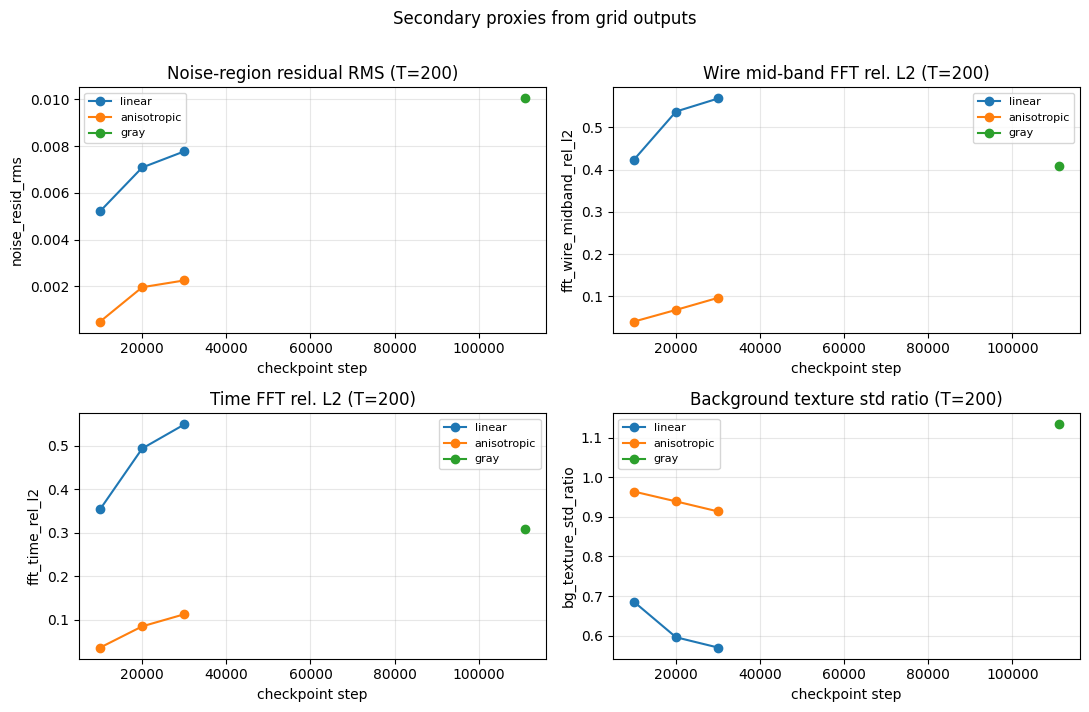


=== validation-plots gallery (if available) ===
linear: no validation-plots under /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/linear
anisotropic: no validation-plots under /exp/sbnd/data/users/munjung/anomaly-detection/training/diffusion/anisotropic
gray: no log_dir


In [18]:
# --- Secondary plots ---
T_SEC = 200

def _sec_series(rows, T, key):
    steps, vals = [], []
    for r in rows:
        prox = r.get("by_T", {}).get(str(T), {})
        if key in prox:
            steps.append(int(r["step"]))
            vals.append(prox[key])
    return steps, vals

metrics = [
    ("noise_resid_rms", "Noise-region residual RMS"),
    ("fft_wire_midband_rel_l2", "Wire mid-band FFT rel. L2"),
    ("fft_time_rel_l2", "Time FFT rel. L2"),
    ("bg_texture_std_ratio", "Background texture std ratio"),
]

if any(secondary_by_config.values()):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.ravel()
    for ax, (key, title) in zip(axes, metrics):
        for cfg, rows in secondary_by_config.items():
            steps, vals = _sec_series(rows, T_SEC, key)
            if steps:
                ax.plot(steps, vals, marker="o", label=cfg)
        ax.set_xlabel("checkpoint step")
        ax.set_ylabel(key)
        ax.set_title(f"{title} (T={T_SEC})")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle("Secondary proxies from grid outputs", y=1.01)
    fig.tight_layout()
    out = STOP_DIR / f"secondary_from_grid_T{T_SEC}.pdf"
    fig.savefig(out, bbox_inches="tight")
    print(f"saved {out}")
    plt.show()
else:
    print("No secondary results.")

# Qualitative validation-plots (from training log dirs, if mounted)
def _resolve_log_dir_local(name: str) -> Path | None:
    if "resolve_log_dir" in globals():
        d = resolve_log_dir(name)
        if d is not None:
            return d
    for base in (
        DATA_ROOT / "training" / "diffusion" / name,
        Path(f"/scratch/7DayLifetime/munjung/anomaly-detection/training/diffusion/{name}"),
    ):
        if base.is_dir():
            return base
    return None

print("\n=== validation-plots gallery (if available) ===")
for name in STOP_CONFIGS:
    log_dir = _resolve_log_dir_local(name)
    if log_dir is None:
        print(f"{name}: no log_dir")
        continue
    vp = log_dir / "validation-plots"
    if not vp.is_dir():
        print(f"{name}: no validation-plots under {log_dir}")
        continue
    for sd in sorted(vp.glob("step-*-ddim")):
        imgs = sorted(sd.glob("img-*"))
        if not imgs:
            continue
        prefer = [p for p in imgs if p.name == "img-3"]
        img_dir = prefer[0] if prefer else imgs[0]
        extras = ["img.png", "reconstructed_t499.png", "reconstructed_t999.png",
                  "time_ffts.png", "wire_ffts.png"]
        paths = [img_dir / e for e in extras if (img_dir / e).is_file()]
        if not paths:
            continue
        fig, axes = plt.subplots(1, len(paths), figsize=(3.2 * len(paths), 3.2))
        if len(paths) == 1:
            axes = [axes]
        for ax, p in zip(axes, paths):
            ax.imshow(mpimg.imread(p))
            ax.set_title(f"{name} {sd.name}\n{p.name}", fontsize=8)
            ax.axis("off")
        fig.tight_layout()
        out = STOP_DIR / f"secondary_gallery_{name}_{sd.name}.pdf"
        fig.savefig(out, bbox_inches="tight")
        print(f"saved {out}")
        plt.show()


### Optional: sync new EMA checkpoints from EAF

Training weights still live on EAF scratch. To refresh shared copies (no inference):

```bash
bash /exp/sbnd/app/users/munjung/anomaly-detection/bin/sync_eaf_checkpoints.sh
```

Then submit grid jobs with `python inference/submit_training_ckpts_grid.py` (from a jobsub host).
